In [ ]:
import cv2
import matplotlib.pyplot as plt

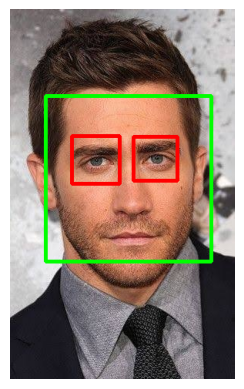

In [ ]:
face_cascade_path = "haarcascade_frontalface_alt.xml" 
eyes_cascade_path = "haarcascade_eye.xml"
face_cascade = cv2.CascadeClassifier(face_cascade_path)
eyes_cascade = cv2.CascadeClassifier(eyes_cascade_path)

if face_cascade.empty() or eyes_cascade.empty():
    raise IOError("loading cascade xml file failed")

image = cv2.imread("image.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = cv2.equalizeHist(gray)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255,0), 4)
    roi_gray = gray[y:y+h, x:x+w]
    eyes = eyes_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(image, (x+ex, y+ey), (x+ex+ew, y+ey+eh), (0, 0, 255), 3)

plt.imshow(image[..., ::-1])
plt.axis('off')
plt.show()

<h2 dir='rtl'>نمایش چهره در تصویر وبکم</h2>

<h2 dir='rtl'>برای خروج از حالت فیلم دکمه Esc را بفشارید.</h2>

In [ ]:
face_cascade_path= 'haarcascade_frontalface_alt.xml'
eyes_cascade_path= 'haarcascade_eye.xml'
face_cascade= cv2.CascadeClassifier(face_cascade_path)
eye_cascade= cv2.CascadeClassifier(eyes_cascade_path)

def detectAndDisplay(frame):
    frame_gray= cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_gray= cv2.equalizeHist(frame_gray)
    faces= face_cascade.detectMultiScale(frame_gray)

    for (x,y,w,h) in faces:
        center= (x + w//2, y + h//2)
        frame= cv2.ellipse(frame, center, (w//2,h//2), 0, 0, 360, (0,255,255), 4)
        faceROI= frame_gray[y:y+h, x:x+w]
        eyes= eyes_cascade.detectMultiScale(faceROI)
        for (ex,ey,ew,eh) in eyes:
            eye_center= (x+ex+ew//2, y+ey+eh//2)
            radius= int(round((ew+eh)*0.25))
            frame= cv2.circle(frame, eye_center, radius, (0,0,255), 5)

    cv2.imshow('Face detection', frame)

cap= cv2.VideoCapture(0)

if not cap.isOpened:
    print("Error , Opening video capture")
    exit(0)

while True:
    ret, frame= cap.read()
    if frame is None:
        print('Error, no captured frame!!')
        break
    fliped= cv2.flip(frame, 1)
    detectAndDisplay(fliped)
    if cv2.waitKey(1)==27:
        break
    
cap.release()
cv2.destroyAllWindows()